# ICA Quality Control — `qc_ica_quality`

Standalone QC for the ds006780 ICA pipeline. Randomly samples ~20–30 subjects
across tasks **from GCS** and checks that ICA **removed artifacts while
preserving brain signal** — both quantitatively and visually.

- **before** = Stage 1 `mne-preproc-pre-ica/*_desc-preproc_eeg.fif`, average-referenced
  here to match Stage 2/3.
- **after** = Stage 3 `mne-ica-apply/*_desc-clean_eeg.fif` (already average-referenced).
- optional context: Stage 3 ICLabel TSVs and the Stage 2 ICA object.

Reads/writes GCS only via `gcs_io.GCSStore`; logs a `qc-ica` W&B run via
`wandb_tracking`. Does **not** modify any stage notebook. Run cells top-to-bottom;
the smoke-test cell (§8) runs one recording before the full batch.

## 1. Setup

In [1]:
import os, time, random, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from mne.preprocessing import read_ica

from asd_eeg import gcs_io
from asd_eeg import wandb_tracking as wbt

try:
    from tqdm.auto import tqdm
except ImportError:                       # tqdm optional
    def tqdm(it, **kw):
        return it

mne.set_log_level('ERROR')
warnings.filterwarnings('ignore', category=RuntimeWarning)

HAS_GCS   = gcs_io.HAS_GCS
HAS_WANDB = wbt.HAS_WANDB
print(f'MNE {mne.__version__} | HAS_GCS={HAS_GCS} | HAS_WANDB={HAS_WANDB}')

MNE 1.10.2 | HAS_GCS=True | HAS_WANDB=True


## 2. Configuration

### 2.1 Paths

In [2]:
PROJECT_ROOT = Path.home() / 'asd_eeg_pipeline'
QC_PIPELINE  = 'qc-ica'                                   # new GCS derivatives prefix
QC_ROOT      = PROJECT_ROOT / 'derivatives' / QC_PIPELINE
FIG_DIR      = QC_ROOT / 'figures'
LOG_DIR      = PROJECT_ROOT / 'derivatives' / 'logs'
LOG_FILE     = LOG_DIR / 'qc_ica_log.csv'
REPORT_FILE  = QC_ROOT / 'qc_report.html'

for d in (QC_ROOT, FIG_DIR, LOG_DIR):
    d.mkdir(parents=True, exist_ok=True)
print('QC outputs ->', QC_ROOT)

QC outputs -> /Users/alirezafatemi/asd_eeg_pipeline/derivatives/qc-ica


### 2.2 GCS source/sink

In [3]:
STAGE1_PIPELINE = 'mne-preproc-pre-ica'   # before (pre-ICA EEG)
STAGE2_PIPELINE = 'mne-ica-fit'           # ICA object (optional metadata)
STAGE3_PIPELINE = 'mne-ica-apply'         # after (clean EEG) + ICLabel TSV

store = gcs_io.GCSStore()
UPLOAD_QC_TO_GCS = True
print('GCS bucket:', store.bucket_name,
      '| available:', store.available() if HAS_GCS else False)

GCS bucket: asd-eeg-dataset | available: True


### 2.3 Sampling

In [4]:
N_SUBJECTS                 = 25
TASKS                      = ['Restingstate', 'FAST', 'IC', 'motor']
RANDOM_SEED                = 42       # fixed for reproducible sampling
MAX_RECORDINGS_PER_SUBJECT = 2        # keep the sample task-varied

### 2.4 Metric parameters

In [5]:
FMIN, FMAX  = 1.0, 45.0
FREQ_BANDS  = {
    'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13),
    'beta':  (13, 30), 'gamma': (30, 45),
}
LINE_FREQ     = 60.0          # power line (already notch+lowpass'd for most tasks)
PSD_N_FFT     = 2048
PLOT_SECONDS  = 10.0
PLOT_CHANNELS = ['Fp1', 'Fp2', 'Cz', 'Oz']   # representative frontal/central/occipital

### 2.5 Experiment tracking (Weights & Biases)
`ENABLE_WANDB=False` makes all tracking a no-op. Set `WANDB_GROUP` to the same id
used in Stages 1–3 to group this QC run with that pipeline configuration.

In [6]:
ENABLE_WANDB = True
WANDB_MODE   = 'online'      # 'online' | 'offline' | 'disabled'
WANDB_GROUP  = None

print(f'W&B tracking: {ENABLE_WANDB}  (mode={WANDB_MODE}, available={wbt.HAS_WANDB})')

W&B tracking: True  (mode=online, available=True)


## 3. Discover & pair (GCS)
Pair Stage 1 (before) with Stage 3 (clean) by `(subject, task, run)`, then join the
Stage 3 ICLabel TSV and Stage 2 ICA object by the same key (attached when present).

In [7]:
def discover_pairs(tasks=TASKS):
    raw   = store.list_files(STAGE1_PIPELINE, '_desc-preproc_eeg.fif', tasks=tasks)
    clean = store.list_files(STAGE3_PIPELINE, '_desc-clean_eeg.fif',   tasks=tasks)
    pairs, missing = gcs_io.GCSStore.pair_files(raw, clean, key_fn=gcs_io.make_key)

    tsv = store.list_files(STAGE3_PIPELINE, '_desc-iclabel_components.tsv', tasks=tasks)
    ica = store.list_files(STAGE2_PIPELINE, '_desc-preproc_ica.fif',        tasks=tasks)
    tsv_by_key = {gcs_io.make_key(ent): ref for ref, ent in tsv}
    ica_by_key = {gcs_io.make_key(ent): ref for ref, ent in ica}

    records = []
    for raw_blob, clean_blob, ent in pairs:
        key = gcs_io.make_key(ent)
        records.append({
            'entities':   ent,
            'raw_blob':   raw_blob,
            'clean_blob': clean_blob,
            'tsv_blob':   tsv_by_key.get(key),
            'ica_blob':   ica_by_key.get(key),
        })
    return records, missing


records, missing = discover_pairs()
n_tsv = sum(r['tsv_blob'] is not None for r in records)
n_ica = sum(r['ica_blob'] is not None for r in records)
print(f'Paired before<->clean: {len(records)} | unmatched (no clean): {len(missing)}')
print(f'  with ICLabel TSV: {n_tsv} | with Stage-2 ICA: {n_ica}')

Paired before<->clean: 2344 | unmatched (no clean): 15
  with ICLabel TSV: 2340 | with Stage-2 ICA: 2344


## 4. Random sampling

In [8]:
def sample_records(records, n_subjects=N_SUBJECTS, seed=RANDOM_SEED,
                   max_per_subject=MAX_RECORDINGS_PER_SUBJECT):
    rng = random.Random(seed)
    by_subject = {}
    for r in records:
        by_subject.setdefault(r['entities']['subject'], []).append(r)

    subjects = sorted(by_subject)
    rng.shuffle(subjects)

    sampled = []
    for sub in subjects[:n_subjects]:
        recs = by_subject[sub][:]
        rng.shuffle(recs)
        seen_tasks, picked = set(), []
        for r in recs:                       # prefer distinct tasks per subject
            t = r['entities']['task']
            if t in seen_tasks:
                continue
            picked.append(r); seen_tasks.add(t)
            if len(picked) >= max_per_subject:
                break
        sampled.extend(picked)
    return sampled


sampled = sample_records(records)
df_sampled = pd.DataFrame([r['entities'] for r in sampled])
if not df_sampled.empty:
    print(f'Sampled {len(sampled)} recordings from '
          f'{df_sampled["subject"].nunique()} subjects')
    print(df_sampled['task'].value_counts())
else:
    print('No recordings sampled — check §3 discovery.')

Sampled 47 recordings from 25 subjects
task
motor           18
Restingstate    15
FAST             7
IC               7
Name: count, dtype: int64


## 5. Quantitative metrics
**Reference invariant:** `apply_average_reference` is called on the Stage 1 *before*
signal only; the Stage 3 clean signal is already average-referenced and is left
untouched. Every before/after/difference comparison is therefore reference-matched.

In [9]:
def apply_average_reference(raw):
    """Replicates Stage 2/3 exactly. Applied to the pre-ICA (before) signal only."""
    raw.set_eeg_reference('average', projection=True, verbose=False)
    raw.apply_proj(verbose=False)
    return raw


def common_eeg_picks(before, clean):
    """EEG channel names present (and good) in both recordings."""
    b = set(before.copy().pick('eeg').ch_names)
    c = set(clean.copy().pick('eeg').ch_names)
    return sorted(b & c)


def welch_psd(raw, picks, fmax):
    psd = raw.compute_psd(method='welch', fmin=1.0, fmax=fmax,
                          picks=picks, n_fft=PSD_N_FFT, verbose=False)
    return psd.get_data(), psd.freqs          # (n_ch, n_freq), (n_freq,)


def _band_power(psd, freqs, lo, hi):
    idx = (freqs >= lo) & (freqs < hi)
    if not idx.any():
        return np.nan
    return float(np.trapz(psd[:, idx], freqs[idx], axis=1).mean())

In [10]:
def compute_metrics(before, clean):
    """Signal-preservation / artifact-reduction metrics. Returns (dict, psd_bundle)."""
    picks = common_eeg_picks(before, clean)
    b = before.copy().pick(picks)
    c = clean.copy().pick(picks)

    Xb, Xc = b.get_data(), c.get_data()
    n = min(Xb.shape[1], Xc.shape[1])
    Xb, Xc = Xb[:, :n], Xc[:, :n]

    var_b, var_c = Xb.var(axis=1), Xc.var(axis=1)
    pct_ch = 1.0 - np.divide(var_c, var_b, out=np.zeros_like(var_c), where=var_b > 0)
    corrs = [np.corrcoef(Xb[i], Xc[i])[0, 1] for i in range(len(picks))]

    m = {
        'n_channels':              len(picks),
        'pct_var_removed':         float(1.0 - Xc.var() / Xb.var()) if Xb.var() else np.nan,
        'pct_var_removed_ch_mean': float(np.nanmean(pct_ch)),
        'pct_var_removed_ch_max':  float(np.nanmax(pct_ch)),
        'mean_corr_before_after':  float(np.nanmean(corrs)),
    }

    sfreq = b.info['sfreq']
    fmax  = min(70.0, sfreq / 2.0 - 1.0)
    Pb, fb = welch_psd(b, picks, fmax)
    Pc, _  = welch_psd(c, picks, fmax)

    for name, (lo, hi) in FREQ_BANDS.items():
        if hi > fmax:
            m[f'retain_{name}'] = np.nan
            continue
        pb, pc = _band_power(Pb, fb, lo, hi), _band_power(Pc, fb, lo, hi)
        m[f'retain_{name}'] = float(pc / pb) if pb and pb > 0 else np.nan

    if LINE_FREQ <= fmax:
        j = int(np.argmin(np.abs(fb - LINE_FREQ)))
        p60b, p60c = Pb[:, j].mean(), Pc[:, j].mean()
        m['line_noise_reduction_db'] = (float(10 * np.log10(p60b / p60c))
                                        if p60c > 0 else np.nan)
    else:
        m['line_noise_reduction_db'] = np.nan          # 60 Hz already filtered out

    return m, (fb, Pb, Pc, picks)

### 5b. ICLabel artifact-specific metrics & Stage 2 ICA metadata
From the Stage 3 ICLabel TSV: how many of which artifact class were removed, the
class split of removed components, and the brain components kept. From the Stage 2
ICA object (when available): explained variance, and the variance explained by the
excluded (artifact) components — i.e. how much signal the removal accounted for.

In [11]:
CLASS_KEYS = {                       # ICLabel label -> short metric key
    'eye blink': 'eye', 'muscle artifact': 'muscle', 'heart beat': 'heart',
    'line noise': 'line_noise', 'channel noise': 'channel_noise',
}
ARTIFACT_KEYS = list(CLASS_KEYS.values())


def load_labels(tsv_path):
    df = pd.read_csv(tsv_path, sep='\t')
    df['exclude'] = df['exclude'].astype(str).str.lower().isin(['true', '1', '1.0'])
    return df


def iclabel_metrics(labels_df):
    n_comp = len(labels_df)
    excl   = labels_df[labels_df['exclude']]
    kept   = labels_df[~labels_df['exclude']]
    n_excl = len(excl)
    counts = excl['label'].value_counts().to_dict()

    m = {'n_components': int(n_comp), 'n_excluded': int(n_excl),
         'frac_excluded': float(n_excl / n_comp) if n_comp else np.nan,
         'n_kept_brain': int((kept['label'] == 'brain').sum()),
         'mean_prob_removed': float(excl['label_probability'].mean()) if n_excl else np.nan,
         'mean_prob_kept': float(kept['label_probability'].mean()) if len(kept) else np.nan}

    for lbl, key in CLASS_KEYS.items():
        n = int(counts.get(lbl, 0))
        m[f'n_removed_{key}']   = n
        m[f'pct_removed_{key}'] = float(n / n_excl) if n_excl else np.nan
    return m


def ica_metadata(ica, before, bad_ics):
    m = {'ica_n_components': int(ica.n_components_)}
    try:
        pca = np.asarray(ica.pca_explained_variance_)
        m['pca_var_top'] = float(pca[:ica.n_components_].sum() / pca.sum())
    except Exception:
        m['pca_var_top'] = np.nan
    try:
        if bad_ics:
            ev = ica.get_explained_variance_ratio(before, components=bad_ics, ch_type='eeg')
            m['var_explained_by_excluded'] = float(ev.get('eeg', np.nan))
            per = []
            for ic in bad_ics:
                e = ica.get_explained_variance_ratio(before, components=[ic], ch_type='eeg')
                per.append(float(e.get('eeg', np.nan)))
            m['var_excl_min']  = float(np.nanmin(per))
            m['var_excl_mean'] = float(np.nanmean(per))
            m['var_excl_max']  = float(np.nanmax(per))
        else:
            m['var_explained_by_excluded'] = 0.0
    except Exception:
        m['var_explained_by_excluded'] = np.nan
    return m

## 6. Per-recording figure
before / clean / **difference** traces (the removed signal), mean PSD overlay,
a variance-removed topomap, and the ICLabel removed/kept breakdown.

In [12]:
def _fig_path(ent):
    parts = [f"sub-{ent['subject']}", f"task-{ent['task']}"]
    if ent.get('run'):
        parts.append(f"run-{ent['run']}")
    return FIG_DIR / ('_'.join(parts) + '_desc-qc.png')


def make_figure(before, clean, ent, psd_bundle, labels_df, metrics):
    fb, Pb, Pc, picks = psd_bundle
    title = f"sub-{ent['subject']} task-{ent['task']}" + (
        f" run-{ent['run']}" if ent.get('run') else '')
    has_labels = labels_df is not None
    ncols = 3 if has_labels else 2
    fig = plt.figure(figsize=(5 * ncols, 8))
    gs = fig.add_gridspec(2, ncols)

    # before / clean / difference traces
    ax_t = fig.add_subplot(gs[:, 0])
    plot_chs = [c for c in PLOT_CHANNELS if c in picks][:4] or picks[:4]
    seg = min(PLOT_SECONDS, float(before.times[-1]))
    b = before.copy().pick(plot_chs).crop(0, seg)
    c = clean.copy().pick(plot_chs).crop(0, seg)
    Xb, Xc, t = b.get_data(), c.get_data(), b.times
    nmin = min(Xb.shape[1], Xc.shape[1], len(t)); t = t[:nmin]
    step = 1.4 * float(np.nanmax(np.abs(Xb[:, :nmin]))) if Xb.size else 1.0
    for i, ch in enumerate(plot_chs):
        off = (len(plot_chs) - i) * step
        ax_t.plot(t, Xb[i, :nmin] + off, color='tab:gray', lw=0.5,
                  label='before' if i == 0 else None)
        ax_t.plot(t, Xc[i, :nmin] + off, color='tab:blue', lw=0.5,
                  label='clean' if i == 0 else None)
        ax_t.plot(t, (Xb[i, :nmin] - Xc[i, :nmin]) + off, color='tab:red', lw=0.5,
                  label='removed' if i == 0 else None)
        ax_t.text(0, off + step * 0.45, ch, fontsize=8, va='bottom')
    ax_t.set_xlabel('time (s)'); ax_t.set_yticks([])
    ax_t.set_title('before / clean / removed'); ax_t.legend(loc='upper right', fontsize=7)

    # mean PSD overlay
    ax_p = fig.add_subplot(gs[0, 1])
    ax_p.semilogy(fb, Pb.mean(0), color='tab:gray', label='before')
    ax_p.semilogy(fb, Pc.mean(0), color='tab:blue', label='clean')
    if LINE_FREQ <= float(fb[-1]):
        ax_p.axvline(LINE_FREQ, color='tab:red', ls=':', lw=0.8)
    ax_p.set_xlabel('Hz'); ax_p.set_ylabel('PSD'); ax_p.set_title('mean PSD')
    ax_p.legend(fontsize=7)

    # variance-removed topomap
    ax_v = fig.add_subplot(gs[1, 1])
    try:
        ba = before.copy().pick(picks); ca = clean.copy().pick(picks)
        Vb, Vc = ba.get_data(), ca.get_data()
        nm = min(Vb.shape[1], Vc.shape[1])
        pct = 1 - Vc[:, :nm].var(1) / np.where(Vb[:, :nm].var(1) > 0,
                                               Vb[:, :nm].var(1), np.nan)
        mne.viz.plot_topomap(np.nan_to_num(pct), ba.info, axes=ax_v, show=False, cmap='Reds')
        ax_v.set_title('frac variance removed')
    except Exception:
        ax_v.text(0.5, 0.5, 'topomap n/a', ha='center'); ax_v.axis('off')

    # ICLabel removed / kept
    if has_labels:
        ax_l = fig.add_subplot(gs[:, 2])
        vals = [metrics.get(f'n_removed_{k}', 0) for k in ARTIFACT_KEYS]
        ax_l.barh(ARTIFACT_KEYS, vals, color='tab:red')
        ax_l.barh(['brain (kept)'], [metrics.get('n_kept_brain', 0)], color='tab:green')
        ax_l.set_xlabel('components'); ax_l.set_title('ICLabel removed / kept')

    fig.suptitle(title)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    return fig

## 7. `process_one` — QC one recording

In [13]:
def process_one(rec):
    ent = rec['entities']
    res = {'status': wbt.STATUS_OK, 'subject': ent['subject'],
           'task': ent['task'], 'run': ent.get('run')}
    try:
        with store.staged(rec['raw_blob']) as rp, store.staged(rec['clean_blob']) as cp:
            before = mne.io.read_raw_fif(rp, preload=True, verbose=False)
            clean  = mne.io.read_raw_fif(cp, preload=True, verbose=False)

            before = apply_average_reference(before)        # match Stage 2/3
            if not clean.info.get('custom_ref_applied'):
                warnings.warn(f'clean signal not custom-referenced: {ent}')

            metrics, psd_bundle = compute_metrics(before, clean)
            res.update(metrics)

            labels_df = None
            if rec['tsv_blob']:
                with store.staged(rec['tsv_blob']) as tp:
                    labels_df = load_labels(tp)
                res.update(iclabel_metrics(labels_df))

            if rec['ica_blob'] and labels_df is not None:
                bad_ics = labels_df.loc[labels_df['exclude'], 'component'].astype(int).tolist()
                with store.staged(rec['ica_blob']) as ip:
                    ica = read_ica(ip, verbose=False)
                res.update(ica_metadata(ica, before, bad_ics))

            fig = make_figure(before, clean, ent, psd_bundle, labels_df, res)
            fp = _fig_path(ent)
            fig.savefig(fp, dpi=110, bbox_inches='tight')
            plt.close(fig)
            res['fig_path'] = str(fp)
    except Exception as e:
        res['status'] = wbt.STATUS_FAILED
        res['error']  = f'{type(e).__name__}: {e}'
    return res

## 8. Smoke test — one recording

In [14]:
assert sampled, 'No sampled recordings — run §3 and §4 first.'
_smoke = process_one(sampled[0])
print('status:', _smoke['status'])
if _smoke['status'] == wbt.STATUS_FAILED:
    print('ERROR:', _smoke.get('error'))
else:
    show = ['subject', 'task', 'pct_var_removed', 'mean_corr_before_after',
            'n_excluded', 'var_explained_by_excluded']
    print({k: _smoke[k] for k in show if k in _smoke})
    print('figure:', _smoke.get('fig_path'))

/var/folders/83/_ppdmr2x49b7rpvgvxpwsfs40000gn/T/ipykernel_26033/978074542.py:12: UserWarning: clean signal not custom-referenced: {'subject': '10752', 'task': 'Restingstate', 'run': '06', 'desc': 'preproc'}
  warnings.warn(f'clean signal not custom-referenced: {ent}')
/var/folders/83/_ppdmr2x49b7rpvgvxpwsfs40000gn/T/ipykernel_26033/22584396.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[:, idx], freqs[idx], axis=1).mean())


status: ok
{'subject': '10752', 'task': 'Restingstate', 'pct_var_removed': 0.2489627385827271, 'mean_corr_before_after': 0.9058158662263642, 'n_excluded': 3, 'var_explained_by_excluded': 0.2489820214524514}
figure: /Users/alirezafatemi/asd_eeg_pipeline/derivatives/qc-ica/figures/sub-10752_task-Restingstate_run-06_desc-qc.png


## 9. Run full QC batch

In [16]:
_t0 = time.time()
results = [process_one(rec) for rec in tqdm(sampled, desc='QC')]

df = pd.DataFrame(results)
df.to_csv(LOG_FILE, index=False)
print(df['status'].value_counts().to_dict(), '->', LOG_FILE)

QC:   0%|          | 0/47 [00:00<?, ?it/s]

/var/folders/83/_ppdmr2x49b7rpvgvxpwsfs40000gn/T/ipykernel_26033/978074542.py:12: UserWarning: clean signal not custom-referenced: {'subject': '10752', 'task': 'Restingstate', 'run': '06', 'desc': 'preproc'}
  warnings.warn(f'clean signal not custom-referenced: {ent}')
/var/folders/83/_ppdmr2x49b7rpvgvxpwsfs40000gn/T/ipykernel_26033/22584396.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(psd[:, idx], freqs[idx], axis=1).mean())
/var/folders/83/_ppdmr2x49b7rpvgvxpwsfs40000gn/T/ipykernel_26033/978074542.py:12: UserWarning: clean signal not custom-referenced: {'subject': '10752', 'task': 'motor', 'run': '02', 'desc': 'preproc'}
  warnings.warn(f'clean signal not custom-referenced: {ent}')
/var/folders/83/_ppdmr2x49b7rpvgvxpwsfs40000gn/T/ipykernel_26033/22584396.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration 

{'ok': 45, 'fail': 2} -> /Users/alirezafatemi/asd_eeg_pipeline/derivatives/logs/qc_ica_log.csv


### 9b. Dataset-level figures, report, and W&B run

wandb: WARNING Artifact "qc-figures" already exists with the same content. No new version will be created.


files/failed,2
files/ok,45
files/processed_this_run,47
files/skipped,0
files/total,47
quality/frac_excluded_mean,0.05823
quality/line_noise_reduction_db_mean,0.83876
quality/mean_corr_before_after_mean,0.91122
quality/n_removed_channel_noise_total,11
quality/n_removed_eye_total,62
+7,...


quality: {'pct_var_removed_mean': 0.21122817685703038, 'mean_corr_before_after_mean': 0.9112163178980607, 'line_noise_reduction_db_mean': 0.8387643675989515, 'frac_excluded_mean': 0.05822869536414055, 'var_explained_by_excluded_mean': 0.21126561955266815, 'n_sampled': 47, 'n_removed_eye_total': 62, 'n_removed_muscle_total': 62, 'n_removed_heart_total': 2, 'n_removed_line_noise_total': 1, 'n_removed_channel_noise_total': 11}


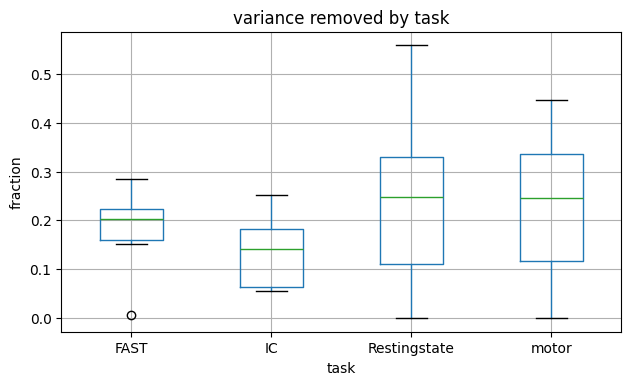

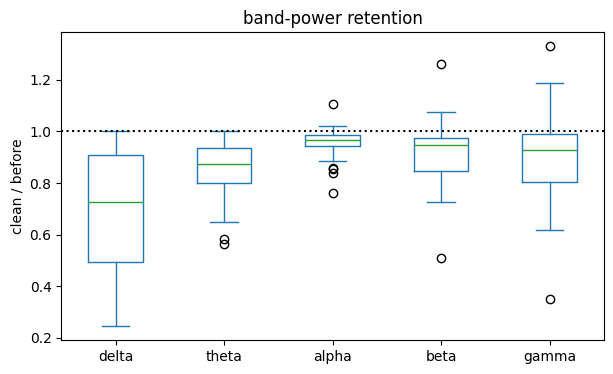

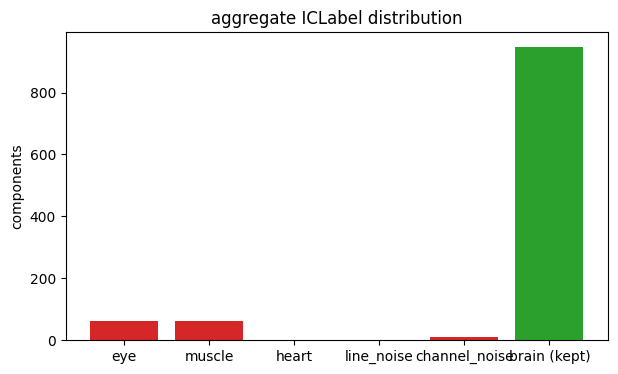

In [18]:
ok_df = df[df['status'] == wbt.STATUS_OK].copy()
figs = {}

if not ok_df.empty:
    if 'pct_var_removed' in ok_df:
        f1, ax = plt.subplots(figsize=(7, 4))
        ok_df.boxplot(column='pct_var_removed', by='task', ax=ax)
        ax.set_title('variance removed by task'); ax.set_ylabel('fraction')
        plt.suptitle(''); figs['pct_var_removed_by_task'] = f1

    band_cols = [f'retain_{b}' for b in FREQ_BANDS if f'retain_{b}' in ok_df]
    if band_cols:
        f2, ax = plt.subplots(figsize=(7, 4))
        ok_df[band_cols].plot.box(ax=ax)
        ax.axhline(1.0, color='k', ls=':'); ax.set_ylabel('clean / before')
        ax.set_title('band-power retention')
        ax.set_xticklabels([c.replace('retain_', '') for c in band_cols])
        figs['band_retention'] = f2

    rcols = [f'n_removed_{k}' for k in ARTIFACT_KEYS if f'n_removed_{k}' in ok_df]
    if rcols:
        f3, ax = plt.subplots(figsize=(7, 4))
        ax.bar([c.replace('n_removed_', '') for c in rcols],
               ok_df[rcols].sum().values, color='tab:red')
        if 'n_kept_brain' in ok_df:
            ax.bar(['brain (kept)'], [ok_df['n_kept_brain'].sum()], color='tab:green')
        ax.set_ylabel('components'); ax.set_title('aggregate ICLabel distribution')
        figs['iclabel_distribution'] = f3


def _mean(col):
    return (float(ok_df[col].mean())
            if col in ok_df and not ok_df[col].dropna().empty else None)


quality = {
    'pct_var_removed_mean':          _mean('pct_var_removed'),
    'mean_corr_before_after_mean':   _mean('mean_corr_before_after'),
    'line_noise_reduction_db_mean':  _mean('line_noise_reduction_db'),
    'frac_excluded_mean':            _mean('frac_excluded'),
    'var_explained_by_excluded_mean': _mean('var_explained_by_excluded'),
    'n_sampled':                     int(len(df)),
}
for k in ARTIFACT_KEYS:
    col = f'n_removed_{k}'
    if col in ok_df:
        quality[f'{col}_total'] = int(ok_df[col].sum())


def write_report(df, figs, path):
    html = ['<html><head><meta charset="utf-8"><title>ICA QC report</title></head><body>',
            f'<h1>ICA QC &mdash; {datetime.now():%Y-%m-%d %H:%M}</h1>',
            f'<p>{len(df)} recordings, {df["subject"].nunique()} subjects, '
            f'tasks: {sorted(df["task"].dropna().unique())}</p>']
    for k, fig in figs.items():
        out = QC_ROOT / f'dataset_{k}.png'
        fig.savefig(out, dpi=110, bbox_inches='tight')
        html.append(f'<h2>{k}</h2><img src="{out.name}" width="640">')
    html.append('<h2>Per-recording metrics</h2>')
    html.append(df.to_html(index=False))
    html.append('</body></html>')
    Path(path).write_text('\n'.join(html))


write_report(df, figs, REPORT_FILE)

run = wbt.init_run(
    stage='qc',
    config={'n_subjects': N_SUBJECTS, 'tasks': TASKS, 'seed': RANDOM_SEED,
            'max_per_subject': MAX_RECORDINGS_PER_SUBJECT,
            'freq_bands': {k: list(v) for k, v in FREQ_BANDS.items()},
            'line_freq': LINE_FREQ},
    group=WANDB_GROUP, enabled=ENABLE_WANDB, mode=WANDB_MODE,
)
# figures artifact must be logged before finalize_run (which finishes the run)
wbt.log_artifact_files(run, 'qc-figures', sorted(FIG_DIR.glob('*.png')), artifact_type='qc')
wbt.finalize_run(
    run, results, namespace='quality',
    wall_seconds=time.time() - _t0,
    log_csv=LOG_FILE, extra_artifacts=[REPORT_FILE],
    plots=figs, quality=quality,
    histogram_columns=['pct_var_removed', 'line_noise_reduction_db',
                       'mean_corr_before_after', 'frac_excluded',
                       'var_explained_by_excluded'],
)
print('quality:', quality)

## 10. Upload QC outputs to GCS

In [19]:
if UPLOAD_QC_TO_GCS and HAS_GCS:
    png = store.upload_tree(QC_ROOT, QC_PIPELINE, '*.png', keep_local=True)
    print(f"PNGs uploaded={len(png['uploaded'])} skipped={len(png['skipped'])} "
          f"failed={len(png['failed'])}")
    for f in (LOG_FILE, REPORT_FILE):
        if f.exists():
            print('->', store.upload(f, f.parent, QC_PIPELINE))
else:
    print('GCS upload skipped (UPLOAD_QC_TO_GCS or HAS_GCS is False).')

GCS upload:   0%|          | 0/48 [00:00<?, ?it/s]

PNGs uploaded=47 skipped=0 failed=1
-> gs://asd-eeg-dataset/derivatives/ds006780/qc-ica/qc_ica_log.csv
-> gs://asd-eeg-dataset/derivatives/ds006780/qc-ica/qc_report.html


## 11. Inspect results

In [20]:
from asd_eeg.utils import read_stage_log
log = read_stage_log(LOG_FILE)
print(log['status'].value_counts().to_dict())

ok = log[log['status'] == 'ok']
metric_cols = [c for c in ['pct_var_removed', 'mean_corr_before_after',
                           'frac_excluded', 'var_explained_by_excluded']
               if c in ok]
if not ok.empty and metric_cols:
    display(ok.groupby('task')[metric_cols].mean().round(3))

# flags worth a manual look
if 'frac_excluded' in ok:
    print('zero-excluded recordings:', int((ok['frac_excluded'] == 0).sum()))
if 'mean_corr_before_after' in ok:
    print('low before/after corr (<0.5):', int((ok['mean_corr_before_after'] < 0.5).sum()))

{'ok': 45, 'fail': 2}


,pct_var_removed,mean_corr_before_after,frac_excluded,var_explained_by_excluded
task,,,,
FAST,0.178,0.924,0.058,0.179
IC,0.134,0.944,0.049,0.134
Restingstate,0.241,0.908,0.024,0.241
motor,0.229,0.897,0.089,0.229


zero-excluded recordings: 3
low before/after corr (<0.5): 0
